In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


Import

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import itertools
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

RANDOM_STATE = 42

CSV_PATH = "/content/drive/MyDrive/Secure_Machine_Learning/MESC.csv"
CHKPTS_DIR = "/content/drive/MyDrive/Secure_Machine_Learning/mesc_emotion_chkpts"

assert os.path.exists(CSV_PATH), f"CSV not found at {CSV_PATH}"
print("Dataset found at", CSV_PATH)


✅ Dataset found at /content/drive/MyDrive/Secure_Machine_Learning/MESC.csv


Loading Dataset

In [ ]:
# Load dataset
df = pd.read_csv(CSV_PATH)ch

# Your file columns: Utterance (text) | Emotion (label)
TEXT_COL = "Utterance"
LABEL_COL = "Emotion"

# Keep only what we need
df = df[[TEXT_COL, LABEL_COL]].dropna().reset_index(drop=True)
df = df[df[TEXT_COL].astype(str).str.strip().ne("")].reset_index(drop=True)

print("Columns:", df.columns.tolist())
print("Total samples:", len(df))
print("Class distribution:", Counter(df[LABEL_COL]))
df.head()


Columns: ['Utterance', 'Emotion']
Total samples: 28762
Class distribution: Counter({'neutral': 17116, 'depression': 4958, 'anger': 2659, 'disgust': 1669, 'joy': 1350, 'sadness': 759, 'fear': 251})


,Utterance,Emotion
0,I told you.,sadness
1,Told me what?,neutral
2,That you'd be sorry you ever encouraged me to ...,sadness
3,I'm not sorry at all.,neutral
4,"You didn't expect it to be like this, I bet.",sadness


In [ ]:
X = df[TEXT_COL].astype(str).values
y = df[LABEL_COL].astype(str).values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")
print("Train class distribution:", Counter(y_train))


Train size: 23009, Test size: 5753
Train class distribution: Counter({'neutral': 13693, 'depression': 3966, 'anger': 2127, 'disgust': 1335, 'joy': 1080, 'sadness': 607, 'fear': 201})


add plots

In [ ]:
tfidf = TfidfVectorizer(
    lowercase=True,
    strip_accents="unicode",
    ngram_range=(1,2),
    min_df=2,
    max_df=0.9,
    max_features=100_000
)


In [ ]:
def train_and_eval(name, pipeline):
    pipeline.fit(X_train, y_train)
    preds = pipeline.predict(X_test)
    acc = accuracy_score(y_test, preds)
    f1m = f1_score(y_test, preds, average="macro")
    print(f"\n=== {name} ===")
    print(f"Accuracy: {acc:.4f} | Macro-F1: {f1m:.4f}")
    return name, acc, f1m, preds


Model

In [ ]:
# 1. SVM
svm_clf = Pipeline([
    ("tfidf", tfidf),
    ("clf", LinearSVC(class_weight="balanced", random_state=RANDOM_STATE))
])

# 2. Logistic Regression
logreg_clf = Pipeline([
    ("tfidf", tfidf),
    ("clf", LogisticRegression(max_iter=4000, class_weight="balanced", solver="lbfgs"))
])

# 3. Neural Network (MLP)
mlp_clf = Pipeline([
    ("tfidf", tfidf),
    ("clf", MLPClassifier(
        hidden_layer_sizes=(512, 256),
        activation="relu",
        batch_size=128,
        max_iter=60,
        learning_rate="adaptive",
        learning_rate_init=1e-3,
        alpha=1e-4,
        early_stopping=False,
        n_iter_no_change=5,
        random_state=RANDOM_STATE
    ))
])

# Dimensionality reduction for tree/KNN
svd = TruncatedSVD(n_components=300, random_state=RANDOM_STATE)

# 4. Random Forest
rf_clf = Pipeline([
    ("tfidf", tfidf),
    ("svd", svd),
    ("clf", RandomForestClassifier(
        n_estimators=600,
        max_features="sqrt",
        class_weight="balanced",
        n_jobs=-1,
        random_state=RANDOM_STATE
    ))
])

# 5. KNN
knn_clf = Pipeline([
    ("tfidf", tfidf),
    ("svd", svd),
    ("clf", KNeighborsClassifier(
        n_neighbors=5,
        weights="distance"
    ))
])

models = [
    ("SVM (LinearSVC)", svm_clf),
    ("Logistic Regression", logreg_clf),
    ("Neural Net (MLP)", mlp_clf),
    ("Random Forest", rf_clf),
    ("KNN", knn_clf)
]
print("Models (with tuned MLP) ready.")


✅ Models (with tuned MLP) ready.


In [ ]:
results = []
pred_store = {}

for name, model in models:
    n, acc, f1m, preds = train_and_eval(name, model)
    results.append({"Model": n, "Accuracy": acc, "Macro_F1": f1m})
    pred_store[n] = preds

results_df = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False).reset_index(drop=True)
results_df


Result

In [ ]:
from IPython.display import display
print("📊 Model Performance:")
display(results_df.style.format({"Accuracy": "{:.4f}", "Macro_F1": "{:.4f}"}))


📊 Model Performance:


,Model,Accuracy,Macro_F1
0,Random Forest,0.5778,0.1608
1,KNN,0.5430,0.1921
2,Neural Net (MLP),0.5314,0.2406
3,SVM (LinearSVC),0.4771,0.2480
4,Logistic Regression,0.3968,0.2424


Best Model: Random Forest

Classification Report:
              precision    recall  f1-score   support

       anger     0.3250    0.0244    0.0455       532
  depression     0.4677    0.0585    0.1039       992
     disgust     0.4324    0.0479    0.0863       334
        fear     0.0513    0.0400    0.0449        50
         joy     0.0761    0.0259    0.0387       270
     neutral     0.6018    0.9407    0.7340      3423
     sadness     0.1143    0.0526    0.0721       152

    accuracy                         0.5778      5753
   macro avg     0.2955    0.1700    0.1608      5753
weighted avg     0.5009    0.5778    0.4680      5753



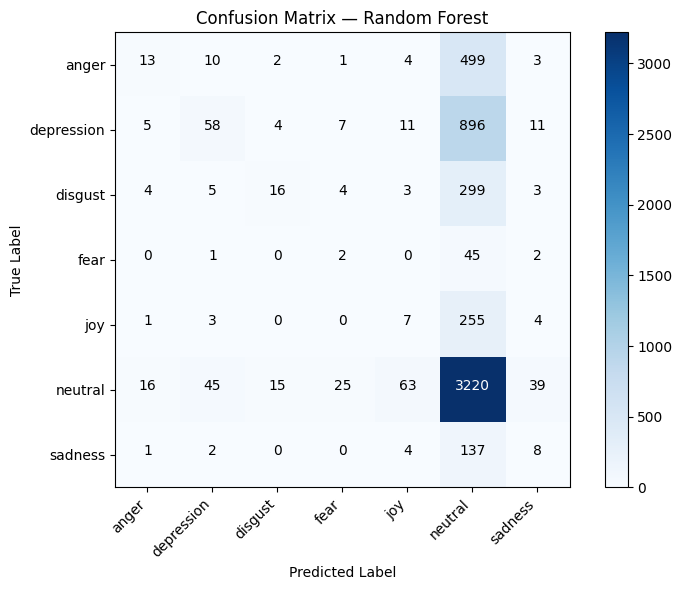

In [ ]:
best_model_name = results_df.iloc[0]["Model"]
best_model = dict(models)[best_model_name]

print("Best Model:", best_model_name)
best_model.fit(X_train, y_train)
preds = best_model.predict(X_test)

print("\nClassification Report:")
print(classification_report(y_test, preds, digits=4))

# Confusion matrix
labels = np.unique(y_test)
cm = confusion_matrix(y_test, preds, labels=labels)

plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix — {best_model_name}")
plt.colorbar()
tick_marks = np.arange(len(labels))
plt.xticks(tick_marks, labels, rotation=45, ha="right")
plt.yticks(tick_marks, labels)

thresh = cm.max() / 2.
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, format(cm[i, j], "d"),
             horizontalalignment="center",
             color="white" if cm[i, j] > thresh else "black")

plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()
